# Creative data layer — does it work, and what is in it?

This notebook has one job: **show that the five creatives were parsed and that the
data is real.** It is the acceptance test for the pipeline and the first look at
the dataset, in that order.

It answers, in sequence:

1. Did every extractor run, on every creative, without failing?
2. What tables exist, and how many rows are in them?
3. What do the five ads actually look like, measured?
4. Where does audience data join on?

Nothing here is modelling. It is verification plus a first read.

> Run `make all` first if the warehouse is empty, then `make notebook`.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

WAREHOUSE = Path(os.environ.get("WAREHOUSE_DIR", "../warehouse"))
DB = WAREHOUSE / "warehouse.duckdb"
assert DB.exists(), f"No warehouse at {DB}. Run `make all` first."

# read_only matters: DuckDB is single-writer, so an open notebook would
# otherwise block the pipeline from running.
con = duckdb.connect(str(DB), read_only=True)
q = lambda sql: con.sql(sql).df()

pd.set_option("display.width", 200, "display.max_columns", 60, "display.max_colwidth", 60)

# Chart styling: recessive grid and axes, ink-coloured text, thin marks.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e8e7e3"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]  # validated order
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c7c6c1", "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600",
    "lines.linewidth": 2, "figure.dpi": 110,
})
print(f"connected to {DB}")

connected to /warehouse/warehouse.duckdb


## 0. Acceptance check

One query, eleven invariants, run before anything else. It asserts, so this
notebook cannot render a clean set of charts over a broken warehouse.

The one that matters most is *every biometric second joins to a creative
second*: that is the join the entire schema was shaped around, and if it holds,
the creative layer and the audience layer genuinely line up.

In [ ]:
# ---------------------------------------------------------------------------
# ACCEPTANCE CHECK -- one query, eleven invariants. If this cell raises, the
# warehouse is not safe to analyse. Everything below it is exploration.
# ---------------------------------------------------------------------------
has_audience = q("""
    SELECT count(*) AS n FROM duckdb_tables() WHERE schema_name = 'audience'
""").n[0] > 0

CREATIVE_CHECKS = """
SELECT 'every extractor run succeeded' AS check_name,
       (SELECT count(*) FILTER (WHERE status = 'ok') || ' of ' || count(*) || ' runs ok'
          FROM run_manifest) AS detail,
       (SELECT count(*) FROM run_manifest WHERE status <> 'ok') = 0 AS passed
UNION ALL
-- run_manifest is append-only history (re-running an extractor after a
-- VERSION bump adds a row), so count distinct pairs, not total runs.
SELECT 'every extractor ran on every creative',
       (SELECT count(DISTINCT creative_id || '|' || extractor) FILTER (WHERE status = 'ok')
               || ' of ' || count(DISTINCT creative_id) * count(DISTINCT extractor)
               || ' (creative, extractor) pairs' FROM run_manifest),
       (SELECT count(DISTINCT creative_id || '|' || extractor) FILTER (WHERE status = 'ok')
             = count(DISTINCT creative_id) * count(DISTINCT extractor) FROM run_manifest)
UNION ALL
SELECT 'every creative has a second-by-second spine',
       (SELECT count(DISTINCT creative_id) || ' of '
               || (SELECT count(*) FROM creatives) FROM creative_seconds),
       (SELECT count(DISTINCT creative_id) FROM creative_seconds)
     = (SELECT count(*) FROM creatives)
UNION ALL
SELECT 'every frame is assigned to a shot',
       (SELECT count(*) FROM creative_frames WHERE shot_index IS NULL)
         || ' frames without a shot',
       (SELECT count(*) FROM creative_frames WHERE shot_index IS NULL) = 0
UNION ALL
-- Cross-check: the spine's own cut flags must reconstruct the shot table.
SELECT 'cuts in the spine reconstruct the shot table',
       (SELECT sum(is_cut)::INT FROM creative_frames) || ' cuts vs '
         || (SELECT count(*) - count(DISTINCT creative_id) FROM shots) || ' expected',
       (SELECT sum(is_cut)::INT FROM creative_frames)
     = (SELECT count(*) - count(DISTINCT creative_id) FROM shots)
UNION ALL
SELECT 'every creative with audio has a transcript',
       (SELECT count(DISTINCT creative_id) || ' of '
               || (SELECT count(*) FROM creatives WHERE has_audio)
          FROM transcript_segments),
       (SELECT count(DISTINCT creative_id) FROM transcript_segments)
     = (SELECT count(*) FROM creatives WHERE has_audio)
"""

AUDIENCE_CHECKS = """
UNION ALL
-- The one that matters: the join the whole schema was designed for.
SELECT 'every biometric second joins to a creative second',
       (SELECT count(*) FROM audience.biometric_seconds b
          LEFT JOIN main.creative_seconds s
            ON s.creative_id = b.creative_id AND s.second = b.second
         WHERE s.creative_id IS NULL) || ' unmatched rows',
       (SELECT count(*) FROM audience.biometric_seconds b
          LEFT JOIN main.creative_seconds s
            ON s.creative_id = b.creative_id AND s.second = b.second
         WHERE s.creative_id IS NULL) = 0
UNION ALL
SELECT 'every session references a real creative',
       (SELECT count(*) FROM audience.sessions s
          LEFT JOIN creatives c USING (creative_id)
         WHERE c.creative_id IS NULL) || ' orphan sessions',
       (SELECT count(*) FROM audience.sessions s
          LEFT JOIN creatives c USING (creative_id)
         WHERE c.creative_id IS NULL) = 0
UNION ALL
-- NULL vs zero: emotions exist exactly when a face was found, never otherwise.
SELECT 'emotions NULL exactly when no face detected',
       (SELECT count(*) FROM audience.biometric_seconds
         WHERE (face_detected AND p_happiness IS NULL)
            OR (NOT face_detected AND p_happiness IS NOT NULL)) || ' violations',
       (SELECT count(*) FROM audience.biometric_seconds
         WHERE (face_detected AND p_happiness IS NULL)
            OR (NOT face_detected AND p_happiness IS NOT NULL)) = 0
UNION ALL
SELECT 'no biometrics recorded without consent',
       (SELECT count(*) FROM audience.biometric_seconds b
          JOIN audience.viewers v USING (viewer_id)
         WHERE NOT v.consent_biometric) || ' rows without consent',
       (SELECT count(*) FROM audience.biometric_seconds b
          JOIN audience.viewers v USING (viewer_id)
         WHERE NOT v.consent_biometric) = 0
UNION ALL
SELECT 'every synthetic row is labelled synthetic',
       (SELECT count(*) FROM audience.biometric_seconds
         WHERE data_source <> 'synthetic_v1') || ' unlabelled rows',
       (SELECT count(*) FROM audience.biometric_seconds
         WHERE data_source <> 'synthetic_v1') = 0
"""

checks = q(CREATIVE_CHECKS + (AUDIENCE_CHECKS if has_audience else ""))
print(f"{int(checks.passed.sum())}/{len(checks)} checks passed"
      f"{'' if has_audience else '   (audience layer not generated -- run `make audience`)'}\n")
for r in checks.itertuples():
    print(f"  {'PASS' if r.passed else 'FAIL'}  {r.check_name:<46} {r.detail}")

assert checks.passed.all(), \
    f"ACCEPTANCE FAILED: {list(checks.loc[~checks.passed, 'check_name'])}"

## 1. Did everything run?

`run_manifest` is written by the pipeline itself, one row per (creative, extractor),
with the extractor version and the sha256 of the video bytes it read. This is the
provenance check: if an extractor had failed, the run would still have completed
(failures do not abort the pipeline) and the failure would show up here.

In [2]:
status = q("""
    SELECT extractor, extractor_version,
           count(*)                                  AS creatives,
           count(*) FILTER (WHERE status = 'ok')     AS ok,
           count(*) FILTER (WHERE status <> 'ok')    AS failed,
           sum(rows_written)                         AS rows_written,
           round(sum(duration_s), 1)                 AS total_s
    FROM run_manifest
    GROUP BY extractor, extractor_version
    ORDER BY total_s DESC
""")
assert status.failed.sum() == 0, "some extractors failed - see run_manifest"
print(f"all {int(status.creatives.sum())} extractor runs OK, "
      f"{int(status.rows_written.sum()):,} rows, {status.total_s.sum():.0f}s total\n")
status

all 50 extractor runs OK, 13,554 rows, 303s total



,extractor,extractor_version,creatives,ok,failed,rows_written,total_s
0,objects,1.0,5,5,0,2381.0,84.9
1,ocr,1.0,5,5,0,1471.0,76.9
2,audio,1.0,5,5,0,1566.0,37.4
3,transcript,1.0,5,5,0,800.0,37.3
4,faces,1.0,5,5,0,1789.0,35.9
5,visual,1.0,5,5,0,1557.0,11.0
6,shots,1.0,5,5,0,99.0,6.8
7,labels,1.0,5,5,0,2178.0,6.5
8,labels,1.1,5,5,0,1683.0,6.4
9,metadata,1.0,5,5,0,30.0,0.3


In [3]:
# Every table in the warehouse, with its row count.
q("""
    SELECT table_name, estimated_size AS rows
    FROM duckdb_tables() WHERE schema_name = 'main'
    ORDER BY rows DESC
""")

,table_name,rows
0,object_detections,2381
1,face_detections,1789
2,shot_label_scores,1683
3,creative_frames,1557
4,screen_text_detections,1471
5,transcript_words,726
6,screen_text,480
7,creative_seconds,391
8,shots,99
9,transcript_segments,69


## 2. The five creatives, measured

`creative_summary` is the one-row-per-ad table. Every column here is derived from
the nine extractors — nothing was entered by hand.

In [4]:
q("""
    SELECT display_name, duration_s, orientation, resolution,
           n_shots, mean_shot_s, cuts_per_minute,
           n_spoken_words, words_per_minute,
           modal_setting, modal_subject, modal_style
    FROM creative_summary ORDER BY duration_s
""")

,display_name,duration_s,orientation,resolution,n_shots,mean_shot_s,cuts_per_minute,n_spoken_words,words_per_minute,modal_setting,modal_subject,modal_style
0,E.L.F Cosmetics Lip Oil - @caro_manning,32.800,vertical,576x1024,6,5.467,9.15,92,168.29,studio,single_person,ugc_selfie
1,E.L.F Cosmetics Lip Oil - @peytonxblack,50.867,vertical,576x1024,11,4.624,11.80,142,167.50,studio,single_person,ugc_selfie
2,The Problem with Attention,69.125,vertical,1080x1920,2,34.563,0.87,251,217.87,indoor,single_person,ugc_selfie
3,Assume that I can - CoorDown,90.001,horizontal,1280x720,57,1.579,37.33,212,141.33,indoor,single_person,cinematic
4,You Are Not Alone - Norwich City,146.541,horizontal,1280x720,23,6.370,9.01,29,11.87,outdoor,two_people,documentary


These five ads are genuinely different animals, and the numbers say so without
anyone watching them:

- **Assume that I can (CoorDown)** — 57 shots in 90s, ~37 cuts/minute. A fast-cut
  cinematic film.
- **The Problem with Attention** — 2 shots in 69 seconds at 218 words/minute. A
  static talking head that never cuts.
- **You Are Not Alone (Norwich City)** — 146s, 29 spoken words. Carried by music
  and picture, not by script.
- **The two e.l.f. clips** — vertical UGC selfies, ~168 wpm, near-continuous speech.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


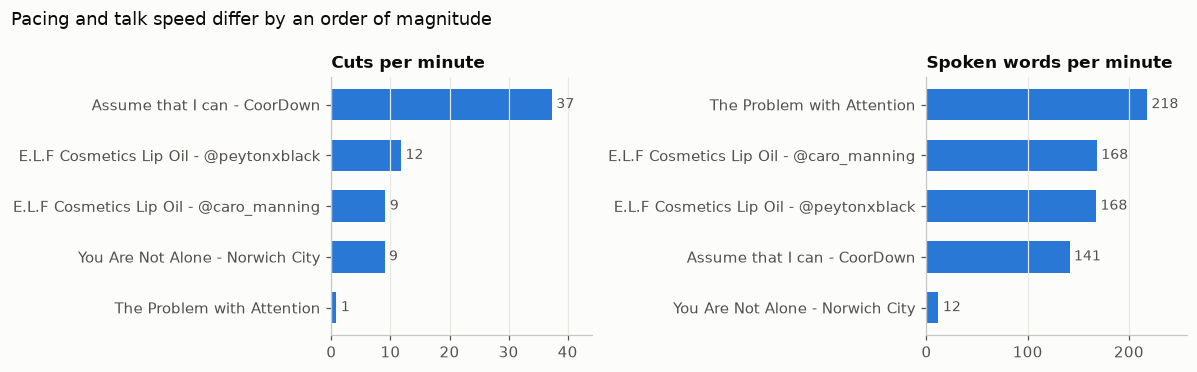

In [5]:
summary = q("""
    SELECT display_name, cuts_per_minute, words_per_minute, duration_s
    FROM creative_summary ORDER BY cuts_per_minute
""")

# Two measures on different scales -> two charts, never two y-axes on one.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, label in zip(axes,
                          ["cuts_per_minute", "words_per_minute"],
                          ["Cuts per minute", "Spoken words per minute"]):
    d = summary.sort_values(col)
    bars = ax.barh(d.display_name, d[col], color=SERIES[0], height=0.62)
    # 4px rounded data-ends would need a custom patch; direct labels instead of
    # a value axis keeps the read immediate.
    for bar, v in zip(bars, d[col]):
        ax.text(bar.get_width() + d[col].max() * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{v:.0f}", va="center", ha="left", color=INK_2, fontsize=9)
    ax.set_title(label, loc="left", color=INK)
    ax.set_xlim(0, d[col].max() * 1.18)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("")
fig.suptitle("Pacing and talk speed differ by an order of magnitude",
             x=0.012, ha="left", fontsize=12, color=INK)
fig.tight_layout()
plt.show()

## 3. The spine: `creative_seconds`

One row per creative per second. This is the table audience data joins onto, and
the table most questions should start from.

In [6]:
q("""
    SELECT second, round(motion,4) AS motion, round(brightness,3) AS brightness,
           round(dbfs,1) AS dbfs, audio_class, n_cuts, max_faces,
           modal_face_emotion, has_screen_text
    FROM creative_seconds
    WHERE creative_id = 'assume-that-i-can-coordown' AND second BETWEEN 10 AND 21
    ORDER BY second
""")

,second,motion,brightness,dbfs,audio_class,n_cuts,max_faces,modal_face_emotion,has_screen_text
0,10,0.0188,0.183,-21.3,speech_over_music,0,1,happiness,True
1,11,0.0423,0.246,-22.5,speech_over_music,1,2,neutral,True
2,12,0.0467,0.302,-19.5,speech_over_music,1,2,neutral,True
3,13,0.0341,0.270,-19.3,speech_over_music,0,1,anger,True
4,14,0.0025,0.196,-21.0,speech_over_music,1,2,neutral,True
5,15,0.0416,0.280,-18.4,speech_over_music,1,1,neutral,True
6,16,0.0528,0.223,-21.9,speech_over_music,1,4,neutral,True
7,17,0.0497,0.265,-18.2,speech_over_music,1,3,neutral,True
8,18,0.0486,0.217,-22.2,speech_over_music,1,3,neutral,True
9,19,0.1915,0.475,-21.1,speech_over_music,0,1,neutral,False


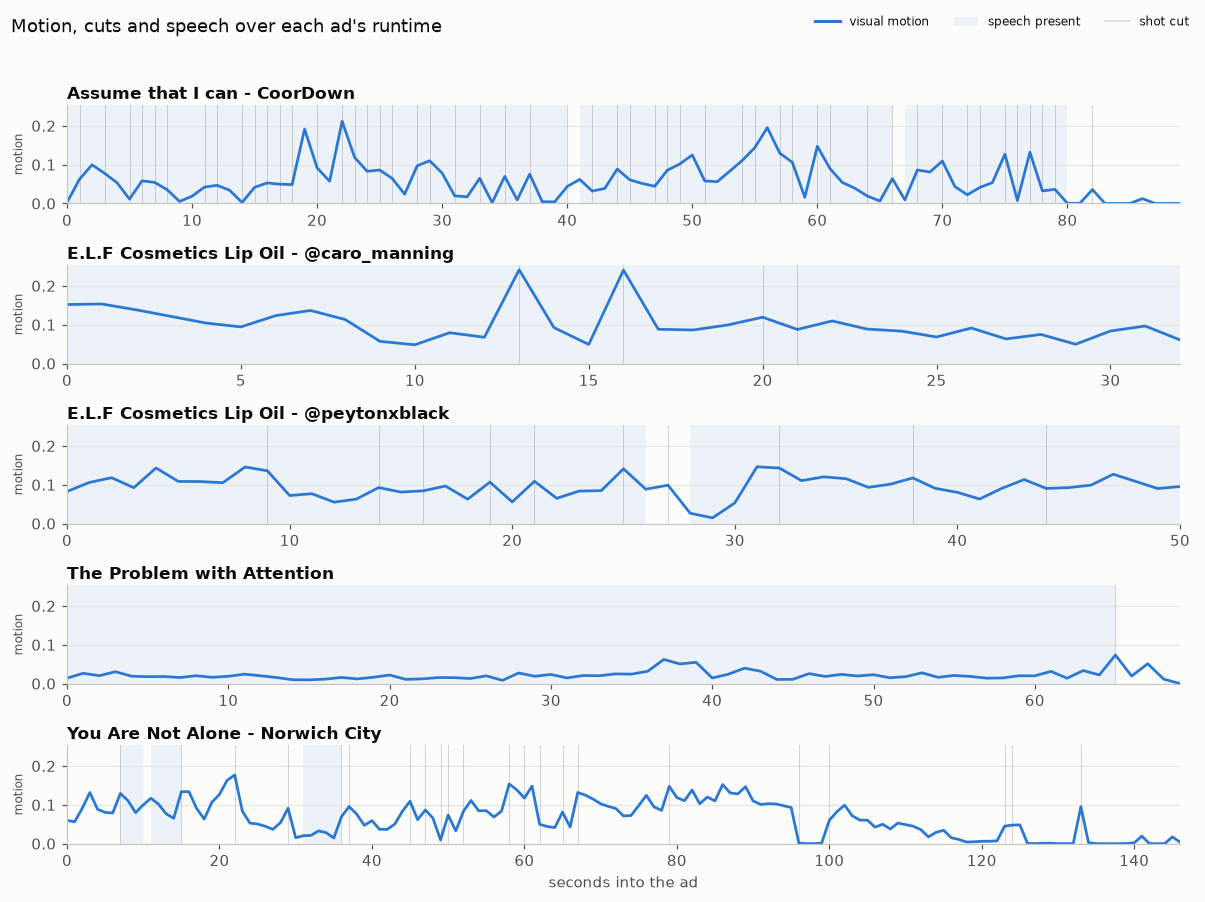

In [7]:
# One facet per creative, one series each -- identity comes from the facet title,
# so colour is not doing work here and stays a single hue.
secs = q("SELECT * FROM creative_seconds ORDER BY creative_id, second")
titles = (q("SELECT creative_id, display_name FROM creatives")
          .set_index("creative_id").display_name.to_dict())
ids = list(titles)

fig, axes = plt.subplots(len(ids), 1, figsize=(11, 1.65 * len(ids)))
for ax, cid in zip(axes, ids):
    d = secs[secs.creative_id == cid]
    ax.plot(d.second, d.motion, color=SERIES[0], linewidth=1.8)
    # Speech is shaded rather than plotted: it is a state, not a magnitude.
    for _, r in d[d.audio_class.isin(["speech", "speech_over_music"])].iterrows():
        ax.axvspan(r.second, r.second + 1, color=SERIES[0], alpha=0.07, linewidth=0)
    for s in d[d.n_cuts > 0].second:
        ax.axvline(s, color=INK_2, alpha=0.22, linewidth=0.7)
    ax.set_title(titles[cid], loc="left", color=INK, pad=4)
    ax.set_xlim(0, d.second.max())
    ax.set_ylim(0, secs.motion.max() * 1.05)
    ax.set_ylabel("motion", fontsize=8)
    ax.grid(axis="x", visible=False)
axes[-1].set_xlabel("seconds into the ad")
handles = [plt.Line2D([], [], color=SERIES[0], lw=2, label="visual motion"),
           mpatches.Patch(facecolor=SERIES[0], alpha=0.07, label="speech present"),
           plt.Line2D([], [], color=INK_2, alpha=0.22, lw=1, label="shot cut")]
# Legend sits above the plotting area so it never covers a trace.
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.995, 0.995),
           frameon=False, fontsize=8, ncol=3)
fig.suptitle("Motion, cuts and speech over each ad's runtime",
             x=0.012, ha="left", fontsize=12, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.962])
plt.show()

The shapes are the story. Norwich City is a long, quiet, music-led film with
sparse speech; the CoorDown spot is a dense picket fence of cuts; the two e.l.f.
clips are wall-to-wall talking with almost no cutting.

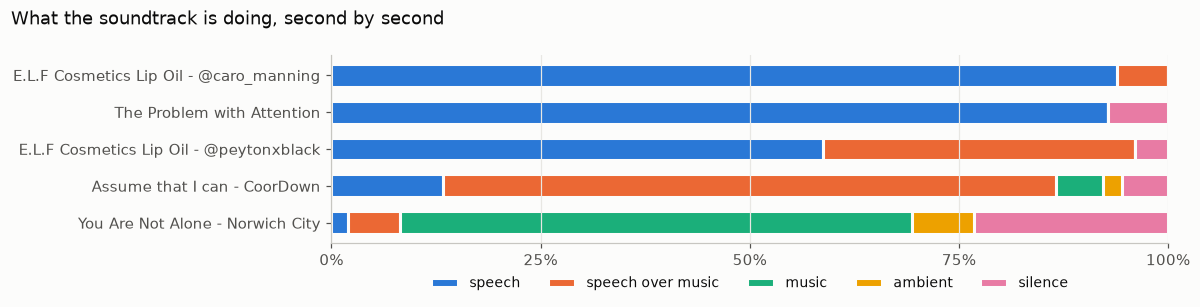

In [8]:
# Stacked shares: categorical slots in the validated order, with a 2px surface
# gap between segments so adjacent fills never touch.
mix = q("""
    SELECT c.display_name, s.audio_class,
           count(*)::DOUBLE / sum(count(*)) OVER (PARTITION BY c.display_name) AS share
    FROM creative_seconds s JOIN creatives c USING (creative_id)
    GROUP BY c.display_name, s.audio_class
""").pivot(index="display_name", columns="audio_class", values="share").fillna(0)

order = [c for c in ["speech", "speech_over_music", "music", "ambient", "silence"]
         if c in mix.columns]
mix = mix[order].sort_values("speech", ascending=True)

fig, ax = plt.subplots(figsize=(11, 3.0))
left = pd.Series(0.0, index=mix.index)
for i, cls in enumerate(order):
    ax.barh(mix.index, mix[cls], left=left, height=0.62,
            color=SERIES[i], label=cls.replace("_", " "),
            edgecolor=SURFACE, linewidth=2)
    left += mix[cls]
ax.set_xlim(0, 1)
ax.set_xticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, ncol=len(order), fontsize=9,
          loc="lower center", bbox_to_anchor=(0.5, -0.32))
fig.suptitle("What the soundtrack is doing, second by second",
             x=0.012, ha="left", fontsize=12, color=INK)
fig.tight_layout()
plt.show()

`audio_class` is the one derived field with judgement in it. Speech is
model-grounded — Whisper runs with Silero VAD — while music-vs-ambient is an
explicit threshold on harmonic ratio and spectral flatness, written in
`transforms/07_creative_seconds.sql` so it can be argued with.

## 4. The language and vision features are real

Spot-checks that the harder extractors produced sensible output rather than noise.

In [9]:
q("""
    SELECT round(start_s,1) AS start_s, round(duration_s,1) AS dur, text
    FROM transcript_segments
    WHERE creative_id = 'e-l-f-cosmetics-lip-oil-caro-manning'
    ORDER BY start_s LIMIT 6
""")

,start_s,dur,text
0,0.0,7.7,You already know I ran and got the brand new elf bundle ...
1,7.7,5.3,This is the crystal baller. Oh my gosh. This is the perf...
2,13.9,8.3,Do you guys see that? That is good. This bundle also com...
3,22.2,3.6,It's only $32 for this whole bundle. That's perfect stoc...
4,25.8,2.3,Or if you're ready to get some more lippies for yourself
5,28.2,3.9,You absolutely need this this quad goals lip kit is so good


In [10]:
# On-screen text, consolidated into spans. Filter on confidence: OCR on stylised
# type over moving video is the noisiest feature in the set.
q("""
    SELECT c.display_name, t.text, t.start_s, t.duration_s,
           t.max_score, t.vertical_position
    FROM screen_text t JOIN creatives c USING (creative_id)
    WHERE t.max_score > 0.90 AND t.is_large_text
    ORDER BY t.duration_s DESC LIMIT 10
""")

,display_name,text,start_s,duration_s,max_score,vertical_position
0,You Are Not Alone - Norwich City,TUS,116.0,8.0,0.9907,lower_third
1,You Are Not Alone - Norwich City,OTUS,32.0,5.0,0.9737,lower_third
2,You Are Not Alone - Norwich City,OT,53.0,5.0,0.9839,lower_third
3,You Are Not Alone - Norwich City,OTUS,62.0,4.0,0.9701,lower_third
4,You Are Not Alone - Norwich City,LOTUS,51.0,3.0,0.9880,lower_third
5,You Are Not Alone - Norwich City,LOTUS,1.0,3.0,0.9961,upper_third
6,You Are Not Alone - Norwich City,OTU,4.0,3.0,0.9906,middle_third
7,You Are Not Alone - Norwich City,LOTUS,68.0,3.0,0.9839,middle_third
8,You Are Not Alone - Norwich City,TUS,110.0,3.0,0.9458,middle_third
9,You Are Not Alone - Norwich City,LOTUS,29.0,3.0,0.9744,lower_third


In [11]:
# Zero-shot shot labels. `conf_*` is the within-axis probability -- filter on it
# before trusting a label.
q("""
    SELECT c.display_name, s.shot_index, round(s.duration_s,1) AS dur,
           s.label_shot_scale, s.label_setting, s.label_subject, s.label_style,
           round(s.conf_setting,2) AS conf_setting, s.object_classes
    FROM shots s JOIN creatives c USING (creative_id)
    WHERE c.creative_id = 'you-are-not-alone-norwich-city'
    ORDER BY s.shot_index LIMIT 8
""")

,display_name,shot_index,dur,label_shot_scale,label_setting,label_subject,label_style,conf_setting,object_classes
0,You Are Not Alone - Norwich City,0,7.5,medium,outdoor,single_person,ugc_selfie,0.66,"person, cell phone, chair"
1,You Are Not Alone - Norwich City,1,7.5,medium,outdoor,hands,cinematic,0.80,"tie, person"
2,You Are Not Alone - Norwich City,2,7.6,medium,outdoor,hands,documentary,0.76,"person, banana, tie"
3,You Are Not Alone - Norwich City,3,6.4,extreme_close_up,outdoor,two_people,documentary,0.47,person
4,You Are Not Alone - Norwich City,4,7.4,extreme_close_up,outdoor,two_people,documentary,0.92,person
5,You Are Not Alone - Norwich City,5,1.0,close_up,outdoor,two_people,cinematic,0.91,"person, tie"
6,You Are Not Alone - Norwich City,6,7.6,medium,outdoor,hands,ugc_selfie,0.49,"person, tie"
7,You Are Not Alone - Norwich City,7,1.9,close_up,outdoor,two_people,documentary,0.92,person


In [12]:
# Faces and expressions. FER+ is heavily neutral-biased -- treat 'neutral' as
# "nothing strong detected" rather than as a finding.
q("""
    SELECT c.display_name,
           count(*)                                     AS face_detections,
           round(avg(f.area_frac), 4)                   AS mean_face_size,
           round(100 * avg(CASE WHEN f.emotion_top='happiness' THEN 1.0 ELSE 0 END), 1) AS pct_happiness,
           round(100 * avg(CASE WHEN f.emotion_top='neutral'   THEN 1.0 ELSE 0 END), 1) AS pct_neutral
    FROM face_detections f JOIN creatives c USING (creative_id)
    GROUP BY c.display_name ORDER BY face_detections DESC
""")

,display_name,face_detections,mean_face_size,pct_happiness,pct_neutral
0,Assume that I can - CoorDown,605,0.0190,7.3,89.4
1,You Are Not Alone - Norwich City,604,0.0402,27.0,70.5
2,The Problem with Attention,262,0.1219,13.7,85.9
3,E.L.F Cosmetics Lip Oil - @peytonxblack,189,0.1556,13.2,76.2
4,E.L.F Cosmetics Lip Oil - @caro_manning,129,0.1889,25.6,65.9


## 5. The audience layer — SYNTHETIC

Everything from here down is **generated, not measured.** It lives in the
`audience` and `analysis` schemas, separate from `main`, and every row carries
`data_source = 'synthetic_v1'`. Nothing below is a finding about these five ads.

The reason to generate it rather than draw random numbers is that the response
is *caused by* the measured creative features: attention at each second is a
function of the cuts, faces, speech and motion that `creative_seconds` records
for that second, plus viewer traits, plus autocorrelated noise. That makes the
creative layer do real work, and makes the join worth testing.

Build it with `make audience`.

In [13]:
# The joined table: one row per viewer-second, every predictor already attached.
q("""
    SELECT session_id, second, attention_index, valence, face_detected,
           n_cuts, creative_has_face, audio_class, age_band, iat_d_score
    FROM analysis.viewer_seconds
    WHERE creative_id = 'assume-that-i-can-coordown'
    ORDER BY session_id, second LIMIT 8
""")

,session_id,second,attention_index,valence,face_detected,n_cuts,creative_has_face,audio_class,age_band,iat_d_score
0,S00003,0,0.8368,-0.0895,True,0,True,speech_over_music,35-44,0.0369
1,S00003,1,0.8992,-0.3476,True,1,True,speech_over_music,35-44,0.0369
2,S00003,2,0.8468,-0.5227,True,0,True,speech_over_music,35-44,0.0369
3,S00003,3,0.9031,-0.2335,True,1,True,speech_over_music,35-44,0.0369
4,S00003,4,0.8150,-0.0631,True,0,True,speech_over_music,35-44,0.0369
5,S00003,5,0.8332,-0.0298,True,1,True,speech_over_music,35-44,0.0369
6,S00003,6,0.8648,0.0591,True,1,True,speech_over_music,35-44,0.0369
7,S00003,7,0.8633,0.1768,True,1,True,speech_over_music,35-44,0.0369


In [14]:
# The coefficients that produced the data are published, so an analysis can be
# checked against ground truth. A real panel has no such table.
q("""
    SELECT component, parameter, value FROM audience.generator_params
    WHERE component = 'attention' ORDER BY abs(value) DESC
""")

,component,parameter,value
0,attention,position_in_ad,-1.30
1,attention,intercept,1.10
2,attention,ar1_rho,0.70
3,attention,viewer_sd,0.60
4,attention,cut_density,0.45
5,attention,has_face,0.35
6,attention,noise_sd,0.35
7,attention,is_speech,0.25
8,attention,motion_z,0.20
9,attention,has_screen_text,-0.15


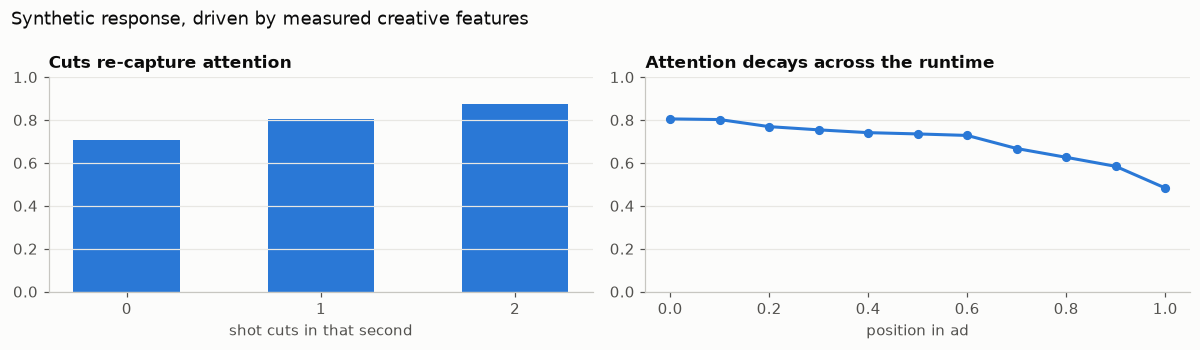

In [15]:
# Two planted effects, visible without any modelling.
by_cuts = q("SELECT n_cuts, round(avg(attention_index),3) AS attention "
            "FROM analysis.viewer_seconds GROUP BY 1 ORDER BY 1")
decay = q("SELECT round(position_in_ad,1) AS position, round(avg(attention_index),3) AS attention "
          "FROM analysis.viewer_seconds GROUP BY 1 ORDER BY 1")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(by_cuts.n_cuts.astype(str), by_cuts.attention, color=SERIES[0], width=0.55)
axes[0].set_title("Cuts re-capture attention", loc="left", color=INK)
axes[0].set_xlabel("shot cuts in that second")
axes[1].plot(decay.position, decay.attention, color=SERIES[0], marker="o", markersize=5)
axes[1].set_title("Attention decays across the runtime", loc="left", color=INK)
axes[1].set_xlabel("position in ad")
for ax in axes:
    ax.set_ylim(0, 1); ax.grid(axis="x", visible=False)
fig.suptitle("Synthetic response, driven by measured creative features",
             x=0.012, ha="left", fontsize=12, color=INK)
fig.tight_layout()
plt.show()

In [16]:
# Completion falling with duration is emergent -- a dropout hazard that rises as
# attention falls, not a rule that was written down.
q("""
    SELECT display_name, duration_s, cuts_per_minute,
           n_sessions, completion_rate, mean_attention, likeability
    FROM analysis.creative_performance ORDER BY completion_rate DESC
""")

,display_name,duration_s,cuts_per_minute,n_sessions,completion_rate,mean_attention,likeability
0,E.L.F Cosmetics Lip Oil - @caro_manning,32.800,9.15,163,0.6503,0.7338,3.166
1,E.L.F Cosmetics Lip Oil - @peytonxblack,50.867,11.80,151,0.5762,0.7213,3.192
2,Assume that I can - CoorDown,90.001,37.33,140,0.3357,0.7618,3.050
3,The Problem with Attention,69.125,0.87,147,0.3333,0.7224,3.061
4,You Are Not Alone - Norwich City,146.541,9.01,148,0.1351,0.7140,3.054


The creative columns above are measured from real video files; the response
columns are generated. Differences between creatives in the response columns are
generator artefacts, not evidence about these ads.

`python -m audience.run validate` runs the integrity and coefficient-recovery
checks: it refits the attention model and confirms the planted coefficients come
back out.

### Next

- `docs/schema.md` — every table, grain, key and column, generated from the warehouse
- `transforms/` and `transforms_audience/` — the SQL that builds each layer
- `audience/contract.py` — the contract a real panel ingest would satisfy
- `warehouse/marts/*.parquet` — the same tables, readable without this repo